# LEARNING OBJECTIVE

This notebook introduces the concept of a streamfunction $\psi$ for a 2D planar flow. It shows how to calculate $\psi(x,y)$ given the components of the velocity $u(x,y)$ and $v(x,y)$, and how to automate this step using symbolic computing tools from SymPy. 

This notebook also provides understanding of the streamfunction, and the various relationships between the streamfunction and the velocity profile, through flow visualization using Matplotlib.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# STREAMFUNCTIONS FOR 2D PLANAR FLOWS

Consider the steady 2D planar flow:
$$
  \underline{v} = \big( v_x(x,y), v_y(x,y), 0 \big).
$$
If the flow is incompressible, $\nabla\cdot\underline{v}=0$, then the two velocity components can be expressed in terms of a _streamfunction_ $\psi(x,y)$ as
$$
  v_x = \partial_y \psi,\qquad v_y = -\partial_x \psi.
$$

In this notebook, we'd like to see how to use streamfunctions, in conjuction with the vector field (flow) visualization tools of [Matplotlib](https://matplotlib.org/stable/gallery/index.html).

## Given $v_x$ and $v_y$

We will use [SymPy](https://docs.sympy.org/latest/tutorial/index.html) and [lambdify](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our functions for evaluation.

In [2]:
x, y, C = sp.symbols('x y C')
vx = sp.Function('vx')(x,y)
vy = sp.Function('vy')(x,y)
psi = sp.Function('psi')(x,y)
F = sp.Function('F')

Example velocity fields (execute only the cell you want; if you "Run All" then only the last velocity field applies).

You can also write your won velocity field. Make sure it is divergence free and make sure to SimPy functions/variables to defined it because at this point it is all symbolic.


In [3]:
# ideal stagnation point
vx = x
vy = -y

In [15]:
# solid body rotation
vx = y
vy = -x

In [26]:
# a cool velocity field (this v field is div-free)
vx = 2*sp.sin(x)*sp.cos(y) - sp.cos(x)*sp.sin(y)
vy = -2*sp.cos(x)*sp.sin(y) + sp.sin(x)*sp.cos(y)

In [27]:
# also 'lambdify' the veloctity for evaluation
lam_vx = sp.lambdify([x, y], vx)
lam_vy = sp.lambdify([x, y], vy)

First, we can visualize the given flow field using a [`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html) plot.


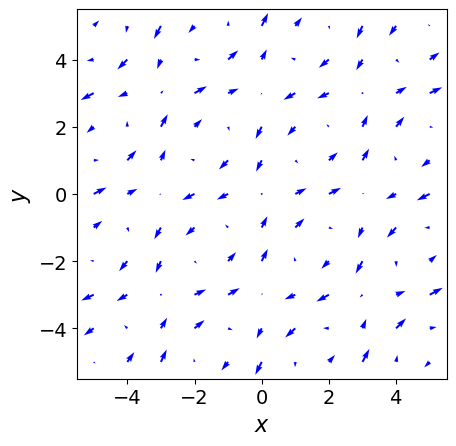

In [28]:
max = 5.0

xp, yp = np.meshgrid( np.linspace(-max, max, num=11),
                      np.linspace(-max, max, num=11) )

fig, ax = plt.subplots()

ax.quiver( xp, yp, lam_vx(xp,yp), lam_vy(xp,yp),
           scale=max, scale_units='xy', # controls arrow size
           color='blue' )

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

plt.show()

## Construct $\psi$

We will use [SymPy](https://docs.sympy.org/latest/tutorial/index.html). That is,

1.   we
undo the $y$ derivative in $\partial_y \psi = v_x$ via an indefinite integral (adding an arbitrary _function_ of integration) as $\psi(x,y) = \int v_x \, dy + F(x)$,
2.   we substitute the later into $\partial_x \psi = -v_y$ to obtain $\int \frac{\partial v_x}{\partial x}\, dy + F'(x) = -v_y$,
3.   we solve the equation from step 2 as an ODE for $F(x)$ given $v_x(x,y)$ and $v_y(x,y)$.

This approach is also proposed at the bottom of the page [here](https://eng.libretexts.org/Bookshelves/Civil_Engineering/Book%3A_All_Things_Flow_-_Fluid_Mechanics_for_the_Natural_Sciences_(Smyth)/05%3A_Fluid_Kinematics/5.02%3A_The_Streamfunction) (but, **warning**, they use the opposite sign convention for $\psi$ from most of fluid mechanics).

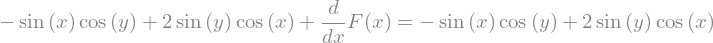

In [29]:
# form the Eq for step 2 above
ODEpsiF = sp.Eq(sp.integrate(vx.diff(x),y)+F(x).diff(x),-vy)
ODEpsiF

The streamfunction is always defined up to a constant of integration, which we can drop or set any way we want. It only affects the values of $\psi$ corresponding to given streamlines, via $\psi(x,y) = const.$, but these values are arbitrary! So, we can impose $F(0)=0$ without loss of generality.

In [30]:
myF = sp.dsolve(ODEpsiF, ics={F(0): 0})
myF.simplify()

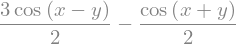

In [31]:
# put psi together via the Eq in step 1 above
psi = sp.integrate(vx,y) + myF.rhs

# see what we got
psi.simplify()

In [32]:
# finally, we also 'lambdify' the streamfunction for evaluation
lam_psi = sp.lambdify([x, y], psi)

"Level sets" of the streamfunctions are curves, $y(x)$ in the plane, such that $\psi\big(x,y(x)\big) = const.$ These curves are the _streamlines_.

The streamfunction itself can be shown in a surface plot, and we can show the streamlines (the "level sets" of $\psi$) as contours, all in one plot, as in this [example](https://matplotlib.org/stable/gallery/mplot3d/contour3d_3.html).

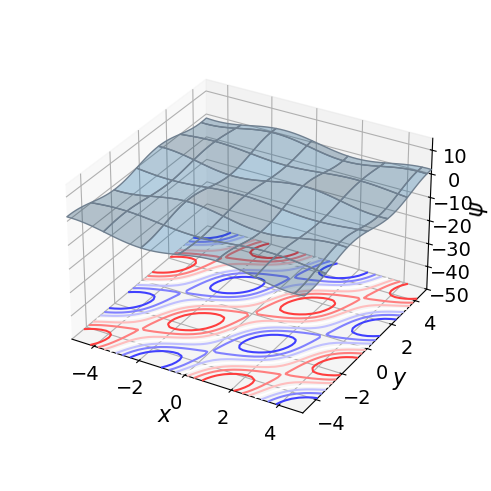

In [33]:
from mpl_toolkits.mplot3d import axes3d

fig, ax = plt.subplots( constrained_layout=True, # for better use of space in plot
                        subplot_kw={"projection": "3d"} )

max = 5.0
xp, yp = np.meshgrid( np.linspace(-max, max, num=51),
                      np.linspace(-max, max, num=51) )

zp = lam_psi(xp,yp)

# plot the 3D surface corresponding to z = psi(x,y)
ax.plot_surface( xp, yp, zp,
                 edgecolor='slategray', # surface color
                 rstride=8, cstride=8, # how many slats to show in meshframe
                 alpha=0.3 ) # transparency of surface

# plot projections of the contours for onyo z direction dimension;
# choosing an 'offset' and the appropriate axes limits,
# the projected contours will sit on the 'walls' of the graph
ax.contour(xp, yp, zp, zdir='z', offset=-50, cmap='bwr')

ax.set(xlim=(-max, max), ylim=(-max, max), zlim=(-50, 15),
       xlabel='$x$', ylabel='$y$', zlabel=r'$\psi$')

# shrink the plot a little to make sure nothing is outside the shown box
ax.set_box_aspect(aspect=(1.5,1.5,1), zoom=0.85)

plt.show()

To better see the streamlines, that is the curves in the $(x,y)$ plane for constant $\psi(x,y)$, we can also directly use [`contour`](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html) from matplotlib.

You can also try [`contourf`](https://matplotlib.org/stable/gallery/images_contours_and_fields/contourf_demo.html) on your own.

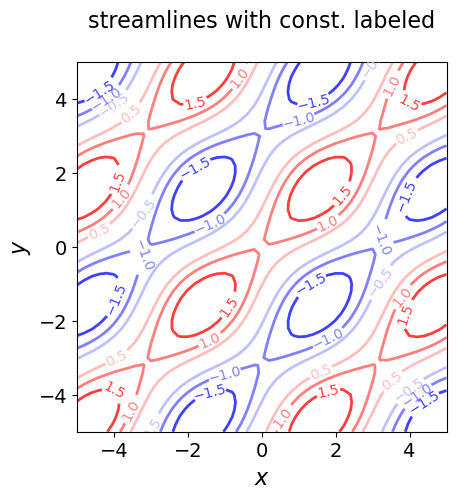

In [34]:
fig, ax = plt.subplots()

max = 5.0
xp, yp = np.meshgrid( np.linspace(-max, max, num=51),
                      np.linspace(-max, max, num=51) )

zp = lam_psi(xp,yp)

# you can specify the values of the 'const.'s in psi(x,y) = const.
# or let it choose its own by not passing this argument
consts = [0, 1, 3, 5, 7, 10, 15, 20]

strm = ax.contour( xp, yp, zp, #consts,
                   linewidths=2, # note this function takes linewidthS, plural...
                   cmap='bwr' )

ax.clabel(strm, inline=True, fontsize=10)

ax.set_title('streamlines with ''const.'' labeled')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

In this plot, I used a [diverging colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html#diverging) to better highlight the regions of $\psi > 0$, $\psi = 0$, and $\psi < 0$.

## Compare the two approaches

The streamlines, $y(x)$, are not only solutions of $\psi\big(x,y(x)\big)=const.$ for some value of the "const.", but also solutions to the differential equation
$$
  \frac{dy}{dx} = \frac{v_y}{v_x},\qquad y(x_0)=y_0,
$$
where the "initial condition" is the starting point, $(x_0,y_0)$, of the streamline and it is related to the "const." above.

This ODE for the streamlines can be solved, for many different values of $(x_0,y_0)$, plotting the resulting curves. That's exactly what [`streamplot`](https://matplotlib.org/stable/gallery/images_contours_and_fields/plot_streamplot.html#sphx-glr-gallery-images-contours-and-fields-plot-streamplot-py) does, solving this ODE numerically.

The result should look similar to the countour plot of $\psi$.

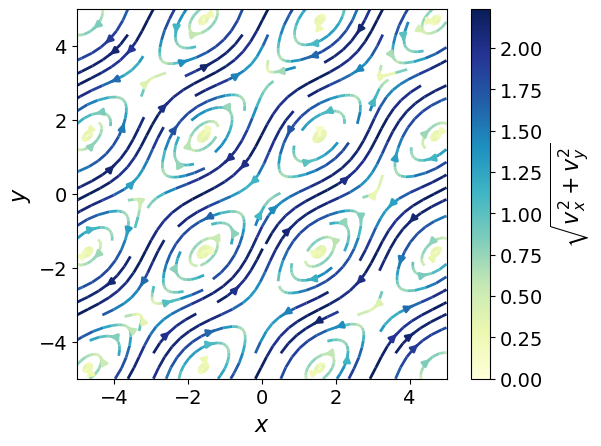

In [35]:
fig, ax = plt.subplots()

max = 5.0
xp, yp = np.meshgrid( np.linspace(-max, max, num=51),
                      np.linspace(-max, max, num=51) )

# plot the streamlines using a 'sequential' color map since the
# velocity magnitude used to color them is always > 0
strm = ax.streamplot( xp, yp, lam_vx(xp,yp), lam_vy(xp,yp),
                      color=np.sqrt(lam_vx(xp,yp)**2 + lam_vy(xp,yp)**2),
                      linewidth=2,
                      cmap=colormaps['YlGnBu'] ) # or YlGnBu_r

plt.colorbar(strm.lines,label=r'$\sqrt{v_x^2+v_y^2}$')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

This plot is nicer because it indicates the sense flow, and the magnitude of velocity via the colors, in addition to showing the streamlines.

For a stream plot, it is good to use a [sequential colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential) since we use the velocity magnitude (always positive) to color the streamlines. Here, lighter colors = slower flow.